In [58]:
import os
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
import itertools
import networkx as nx

import dcor
import scipy as sp
from nlcor import nlcor
from PyIF import te_compute as te
from sklearn.feature_selection import mutual_info_regression as MI

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from connectivity import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [59]:
def plot_weighted_graph(G, N, ifSave = False, savePath='', figsize = (8, 8)):
    "Plotting the weighted graph"
    
    plt.figure(figsize = figsize)
    # Adding nodes 
    pos = nx.spring_layout(G) 
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', edgecolors='darkblue', node_size=800)

    # Adding labels to the nodes
    labels = {}
    for n in range(N):
        labels[n] = f"B{n+1:02d}"
    nx.draw_networkx_labels(G,pos,labels,font_size=10)

    all_weights = []
    #4 a. Iterate through the graph nodes to gather all the weights
    for (node1, node2, data) in G.edges(data = True):
        all_weights.append(data['weight']) 

    #4 b. Get unique weights
    unique_weights = list(set(all_weights))
 
    #4 c. Plot the edges - one by one!
    for weight in unique_weights:
        #4 d. Form a filtered list with just the weight you want to draw
        weighted_edges = [(node1,node2) for (node1,node2,edge_attr) in G.edges(data=True) if edge_attr['weight']==weight]
        nx.draw_networkx_edges(G, pos, edge_color='darkblue', alpha = weight, edgelist = weighted_edges,width = 2.5)
 
    #Plot the graph
    plt.axis('off')
    plt.title(f"Graph Network (N = {N})")

    if ifSave:
        plt.savefig(savePath) 
    plt.show() 

In [60]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
nTrials = 10

params['N'] = nNodes = 4    # Network size

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

In [61]:
t_start = 1000
t_end = T

In [62]:
def euler_intergrate(u, init_point, modNodes, **opts):
    # common parameters
    beta = opts.get('beta')
    gamma = opts.get('gamma')
    theta = opts.get('theta')

    nTrials, N = init_point.shape
    nNodes = N // 2

    for q in range(nTrials):
        u[q, :, 0] = init_point[q, :]

        for t in range(opts.get('T') - 1):
            Fvect = np.zeros((2 * nNodes, 1))
            Imod = np.zeros((2 * nNodes, 1))

            for n in range(nNodes):
                Fvect[2 * n] = F(u[q, 2 * n, t], beta, theta, gamma, opts.get('sigma')[2 * n])
                Fvect[2 * n + 1] = F(u[q, 2 * n + 1, t], beta, theta, gamma, opts.get('sigma')[2 * n + 1])

                Imod[2 * n] = opts.get('i_mod') if n in modNodes else 0

            uVect = -u[q, :, t].reshape(-1, 1) + opts.get('W') @ Fvect + opts.get('Kglob') * opts.get('Pbar') @ u[q, :, t].reshape(-1, 1) + opts.get('i_bias') + Imod
            uVect = opts.get('dt') * opts.get('Tau') @ uVect
            u[q, :, t + 1] = u[q, :, t] + uVect.flatten()        
    return u

In [63]:
# Random initialization
xInit = np.random.uniform(minval, maxval, (nTrials, 2 * nNodes))

In [64]:
# (1) Creating a directed graph from source to a chain of targets (for dynamic progression)

A = np.zeros((nNodes, nNodes))

for n in range(1, nNodes):
    A[n, n - 1] = 1

print(A)


[[0. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]


In [65]:
Dnet= np.zeros((nNodes, 2 * nNodes))

for n in range(nNodes):
    Dnet[n, 2 * n : 2 * n + 2] = np.array([1, 0])

params['Pbar'] = Pbar = (Dnet.T @ A) @ Dnet
print(Pbar)


[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [66]:
tau = np.diag(np.array([1 / params['tau_e'], 1 / params['tau_i']]))
params['Tau'] = Tau = np.kron(np.eye(nNodes), tau)

w = np.array([[params['wee'], params['wie']], [params['wei'], params['wii']]])
params['W'] = W = np.kron(np.eye(nNodes), w)

In [67]:
ibias = np.array([params['i_ebias'], params['i_ibias']])
params['i_bias'] = i_bias = np.repeat(ibias[np.newaxis,...], nNodes, axis=0).flatten().reshape(-1, 1)

In [68]:
sige = 2.5 + 0.01 * np.random.randn(nNodes)
sigi = 4.4 + 0.01 * np.random.randn(nNodes)

In [69]:
params['Kglob'] = 0.8
params['i_mod'] = 0.5 / params['gamma']

sigma = np.ones(2 * nNodes)

for n, (se, si) in enumerate(zip(sige, sigi)):
    sigma[2 * n] = se
    sigma[2 * n + 1] = si

# setting the source heterogeneity values
sigma[0] = 2.5
sigma[1] = 4.4

params['sigma'] = sigma
print(sigma)

[ 2.5         4.4         7.790986   16.49666518  7.79806373 16.50568946
  7.80414925 16.49311691]


In [70]:
u = np.zeros((nTrials, 2 * nNodes, T))
u = euler_intergrate(u, xInit, modNodes = [0], **params)

Text(0.5, 0.01, 'Time (a.u.)')

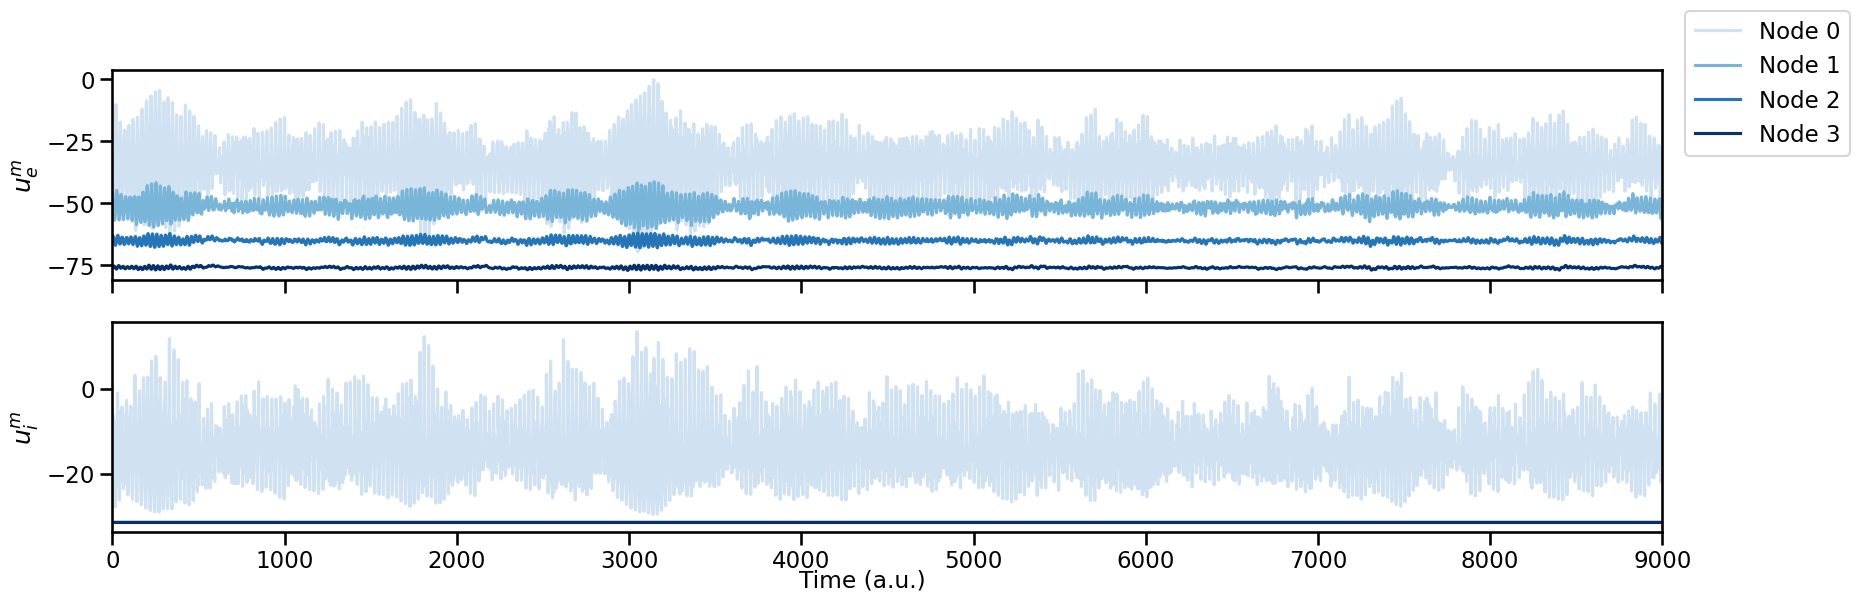

In [71]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 6))
axs[0].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))
axs[1].set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))

for n in range(nNodes):
    ue = np.mean(u[:, 2 * n, t_start :], axis=0)
    ui = np.mean(u[:, 2 * n + 1, t_start :], axis=0)
    axs[0].plot(time_[:-t_start], ue)
    axs[1].plot(time_[:-t_start], ui, label=f"Node {n}")

axs[0].set_ylabel(r"$u_e^m$")
axs[0].set_xlim(0, t_end - t_start)
axs[1].set_ylabel(r"$u_i^m$")
axs[1].set_xlim(0, t_end - t_start)
fig.legend()
fig.supxlabel('Time (a.u.)')

    

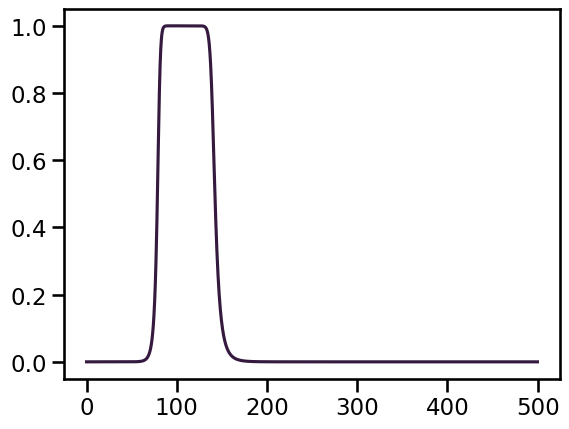

In [72]:
Fs = 1000
def butter_bandpass(lowcut, highcut, fs, order=5):
    return sp.signal.butter(order, [lowcut, highcut], fs=fs, btype='band')

b, a = butter_bandpass(lowcut = 80, highcut = 140, fs = Fs, order=9)
w, h = sp.signal.freqz(b, a, fs=Fs, worN=2000)
plt.plot(w, abs(h))
filssigs = []

for n in range(nNodes):
    filssigs.append(sp.signal.lfilter(b, a, np.mean(u[:, 2 * n, : ], axis=0)))

Text(0.5, 0, 'Time (a.u.)')

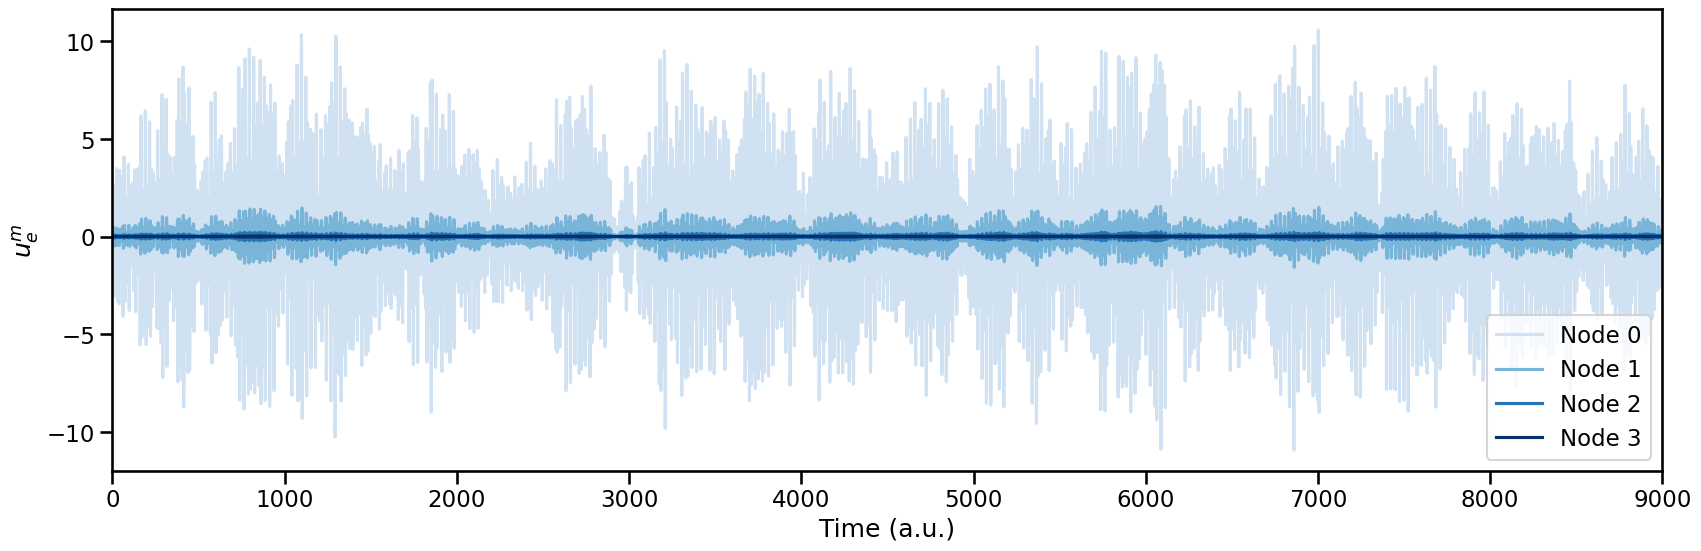

In [73]:
plt.figure(figsize=(20, 6))
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))

for n in range(nNodes):
    plt.plot(time_[:-t_start], filssigs[n][t_start :], label=f"Node {n}")

plt.ylabel(r"$u_e^m$")
plt.xlim(0, t_end - t_start)
plt.legend()
plt.xlabel('Time (a.u.)')

In [74]:
lyapunov_series = np.zeros((nNodes, T - t_start - 1))

for n in range(nNodes):
    for q in range(nTrials):
        lyapunov_series[n, :] += (1 / nTrials) * np.log(np.abs(np.diff(u[q, 2 * n, t_start : ])))

Text(0.5, 0, 'Time (a.u.)')

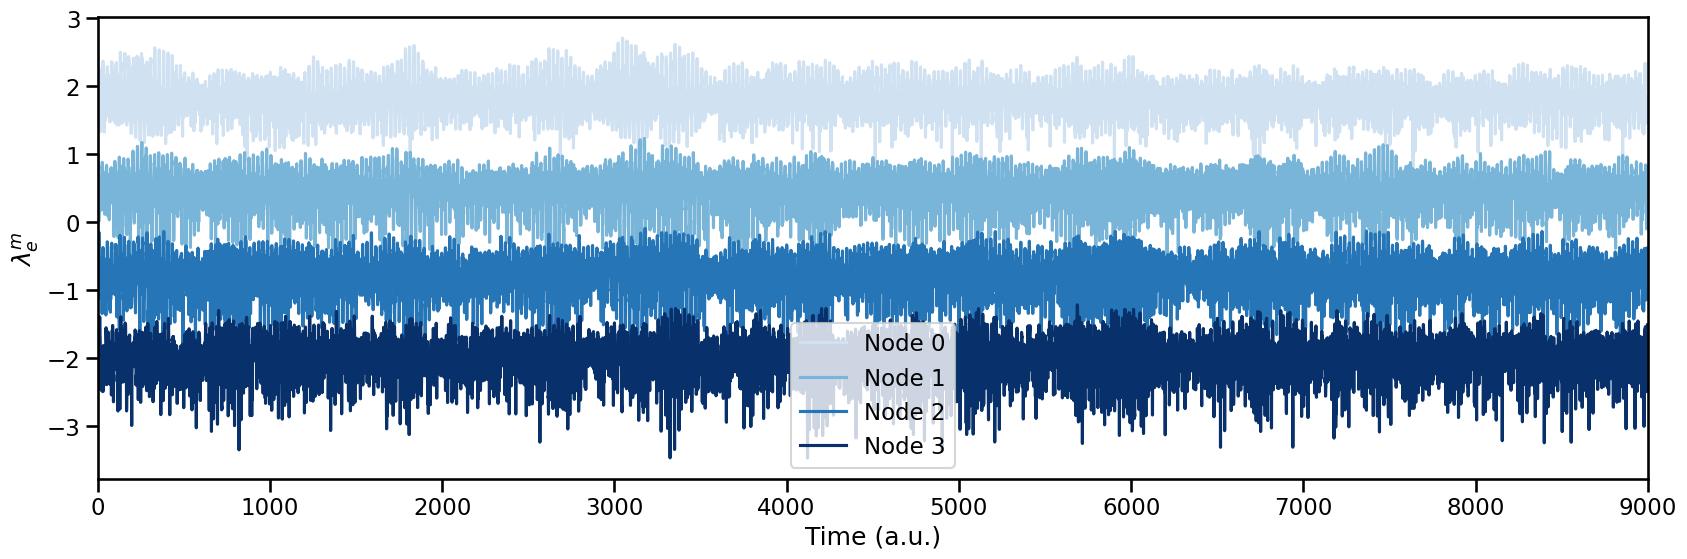

In [75]:
plt.figure(figsize=(20, 6))
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, nNodes))))

for n in range(nNodes):
    plt.plot(time_[:-t_start-1], lyapunov_series[n], label=f"Node {n}")

plt.ylabel(r"$\lambda_e^m$")
plt.xlim(0, t_end - t_start)
plt.legend()
plt.xlabel('Time (a.u.)')

In [87]:
FP = np.zeros((nNodes, nNodes))
FP_vect = np.zeros(int(nNodes * (nNodes - 1) / 2))

for q in range(nTrials):
    data = u[q, 0 :: 2, t_start : ]
    connect_matrix, connect_vector = plv_connectivity(nNodes, data)

    FP += connect_matrix
    FP_vect += connect_vector

FP /= nTrials
FP_vect /= nTrials

PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!
PLV in process.....
PLV done!


In [89]:
FP = FP - np.eye(nNodes)

In [91]:
sum(FP_vect) / (nNodes * (nNodes - 1) / 2)

0.8767592462037918

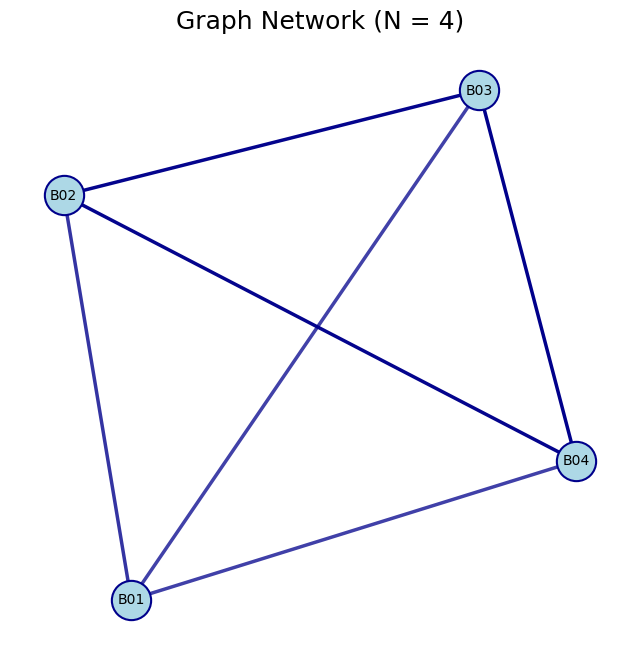

In [92]:
G = nx.from_numpy_array(FP, parallel_edges=True)
plot_weighted_graph(G, N = nNodes)

PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
PLI in process.....
PLI done!
0.3191925925925926


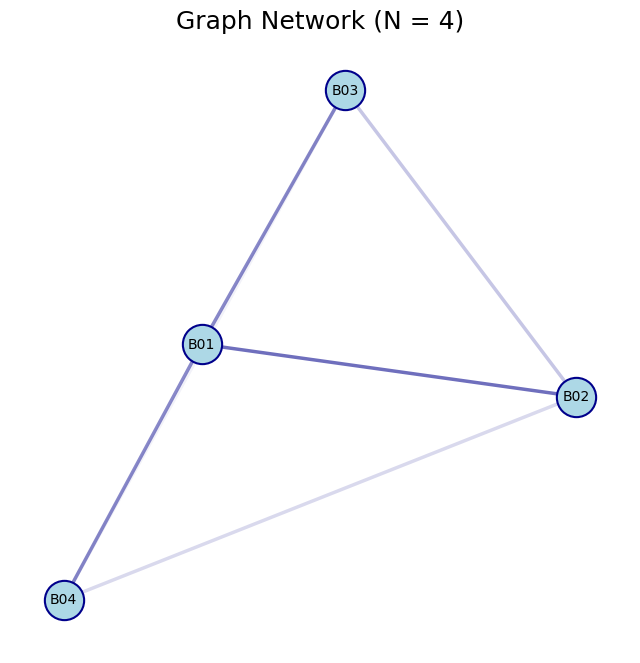

In [95]:
FP = np.zeros((nNodes, nNodes))
FP_vect = np.zeros(int(nNodes * (nNodes - 1) / 2))

for q in range(nTrials):
    data = u[q, 0 :: 2, t_start : ]
    connect_matrix, connect_vector = pli_connectivity(nNodes, data)

    FP += connect_matrix
    FP_vect += connect_vector

FP /= nTrials
FP_vect /= nTrials

FP = FP
print(sum(FP_vect) / (nNodes * (nNodes - 1) / 2))

G = nx.from_numpy_array(FP, parallel_edges=True)
plot_weighted_graph(G, N = nNodes)

CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
CCF in process.....
CCF done!
0.45017843511142525


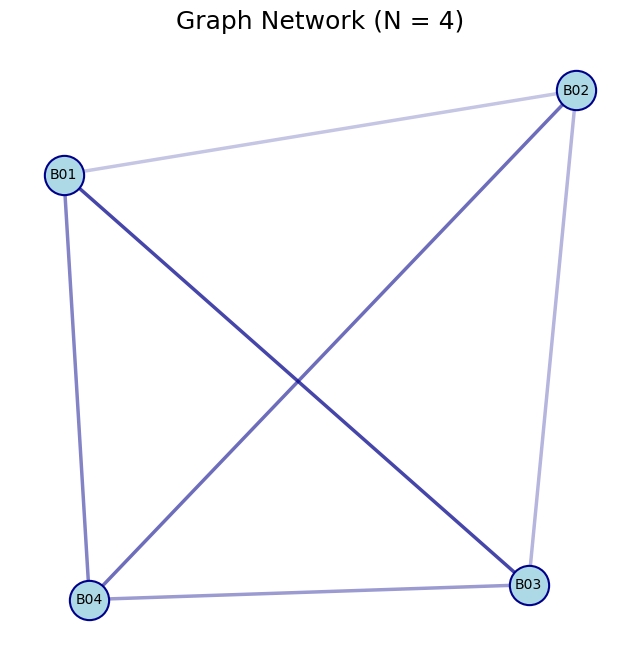

In [100]:
FP = np.zeros((nNodes, nNodes))
FP_vect = np.zeros(int(nNodes * (nNodes - 1) / 2))

for q in range(nTrials):
    data = u[q, 0 :: 2, t_start : ]
    connect_matrix, connect_vector = ccf_connectivity(nNodes, data)

    FP += connect_matrix
    FP_vect += abs(connect_vector)

FP /= nTrials
FP_vect /= nTrials

FP = FP - np.eye(nNodes)
print(sum(FP_vect) / (nNodes * (nNodes - 1) / 2))

G = nx.from_numpy_array(abs(FP), parallel_edges=True)
plot_weighted_graph(G, N = nNodes)

COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
COH in process.....
COH done!
0.9980570952632556


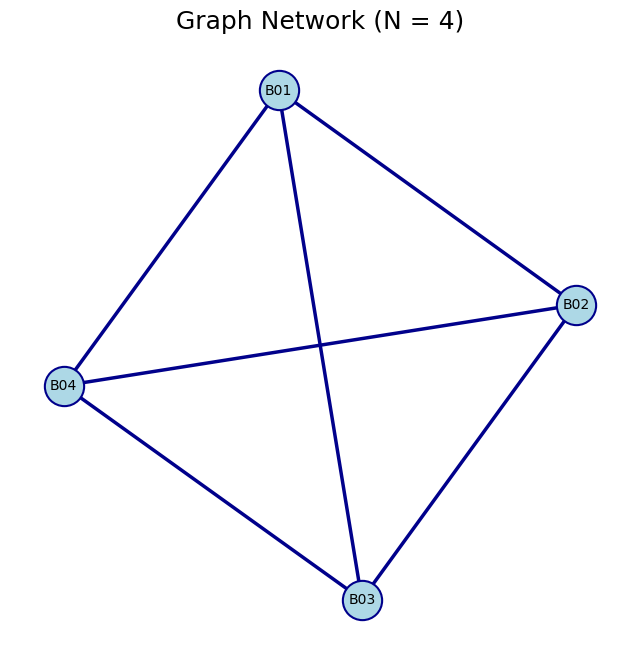

In [103]:
FP = np.zeros((nNodes, nNodes))
FP_vect = np.zeros(int(nNodes * (nNodes - 1) / 2))

for q in range(nTrials):
    data = u[q, 0 :: 2, t_start : ]
    connect_matrix, connect_vector = coh_connectivity(nNodes, data, 80, 140, 1000)

    FP += connect_matrix
    FP_vect += connect_vector

FP /= nTrials
FP_vect /= nTrials

FP = FP - np.eye(nNodes)
print(sum(FP_vect) / (nNodes * (nNodes - 1) / 2))

G = nx.from_numpy_array(FP, parallel_edges=True)
plot_weighted_graph(G, N = nNodes)

ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
ICOH in process.....
ICOH done!
0.747165761922081


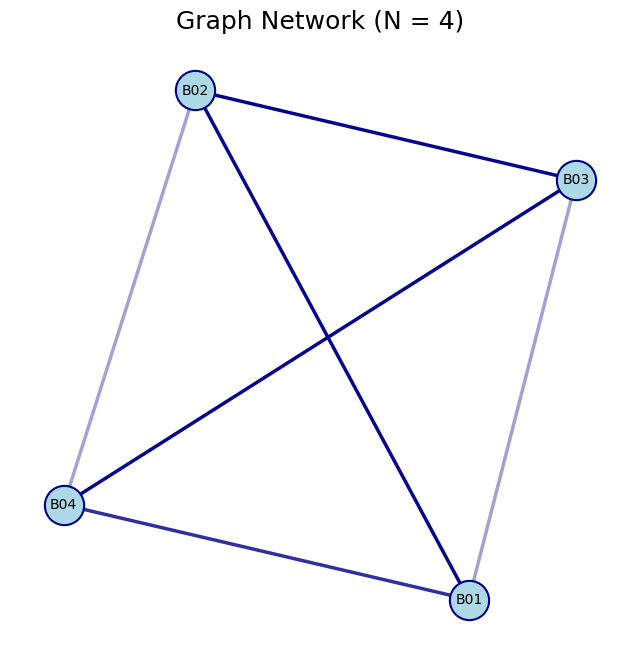

In [109]:
FP = np.zeros((nNodes, nNodes))
FP_vect = np.zeros(int(nNodes * (nNodes - 1) / 2))

for q in range(nTrials):
    data = u[q, 0 :: 2, t_start : ]
    connect_matrix, connect_vector = icoh_connectivity(nNodes, data, 80, 140, 1000)

    FP += connect_matrix
    FP_vect += abs(connect_vector)

FP /= nTrials
FP_vect /= nTrials

FP = FP
print(sum(FP_vect) / (nNodes * (nNodes - 1) / 2))

G = nx.from_numpy_array(abs(FP), parallel_edges=True)
plot_weighted_graph(G, N = nNodes)

In [108]:
FP

array([[ 0.        , -0.97840078,  0.36709884,  0.81434375],
       [ 0.97840078,  0.        , -0.97846356,  0.36620895],
       [-0.36709884,  0.97846356,  0.        , -0.97847868],
       [-0.81434375, -0.36620895,  0.97847868,  0.        ]])